In [ ]:
!pip install kaggle --quiet

import os, zipfile, shutil
from pathlib import Path


try:
    from google.colab import files
    print("📤 ارفع ملف kaggle.json ...")
    uploaded = files.upload()

    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    shutil.move("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    print("✅ kaggle.json اتحط في ~/.kaggle/")

except ImportError:
    kaggle_path = Path.home() / ".kaggle" / "kaggle.json"
    if kaggle_path.exists():
        print(f"✅ kaggle.json موجود في {kaggle_path}")
    else:
        print("❌ حط ملف kaggle.json في:", kaggle_path)
        print("   حمّله من: kaggle.com → Account → Create New Token")


📤 ارفع ملف kaggle.json ...


Saving kaggle.json to kaggle.json
✅ kaggle.json اتحط في ~/.kaggle/


## 📥 2. Download Dataset

 Four catigories in **Yawn Eye Dataset**:
- `Closed eye`
- `Open eye`
- `yawn`
- `no_yawn`


In [ ]:
import subprocess

DATASET   = "serenaraju/yawn-eye-dataset-new"
DATA_DIR  = Path("./data/drowsiness")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"📥 بيحمل: {DATASET} ...")
result = subprocess.run(
    ["kaggle", "datasets", "download", "-d", DATASET,
     "-p", str(DATA_DIR), "--unzip"],
    capture_output=True, text=True
)

if result.returncode == 0:
    print("✅ اتحمل بنجاح!")
else:
    print("❌ Error:", result.stderr)
    print("تأكد إن kaggle.json صح وعندك اتصال بالنت")

print("\n📂 محتوى الـ dataset:")
for p in sorted(DATA_DIR.rglob("*"))[:30]:
    indent = "  " * (len(p.parts) - len(DATA_DIR.parts) - 1)
    icon   = "📁" if p.is_dir() else "🖼️"
    print(f"  {indent}{icon} {p.name}")


📥 بيحمل: serenaraju/yawn-eye-dataset-new ...
✅ اتحمل بنجاح!

📂 محتوى الـ dataset:
  📁 dataset_new
    📁 test
      📁 Closed
        🖼️ _107.jpg
        🖼️ _115.jpg
        🖼️ _116.jpg
        🖼️ _120.jpg
        🖼️ _129.jpg
        🖼️ _130.jpg
        🖼️ _132.jpg
        🖼️ _137.jpg
        🖼️ _14.jpg
        🖼️ _148.jpg
        🖼️ _152.jpg
        🖼️ _159.jpg
        🖼️ _161.jpg
        🖼️ _163.jpg
        🖼️ _164.jpg
        🖼️ _167.jpg
        🖼️ _168.jpg
        🖼️ _169.jpg
        🖼️ _172.jpg
        🖼️ _181.jpg
        🖼️ _195.jpg
        🖼️ _197.jpg
        🖼️ _20.jpg
        🖼️ _211.jpg
        🖼️ _214.jpg
        🖼️ _216.jpg
        🖼️ _219.jpg


## 🔍 3. Discover Dataset

📊 إجمالي الصور: 2,900
   الفئات: Counter({'Closed': 726, 'Open': 726, 'no_yawn': 725, 'yawn': 723})

   Class names: ['Closed', 'Open', 'no_yawn', 'yawn']


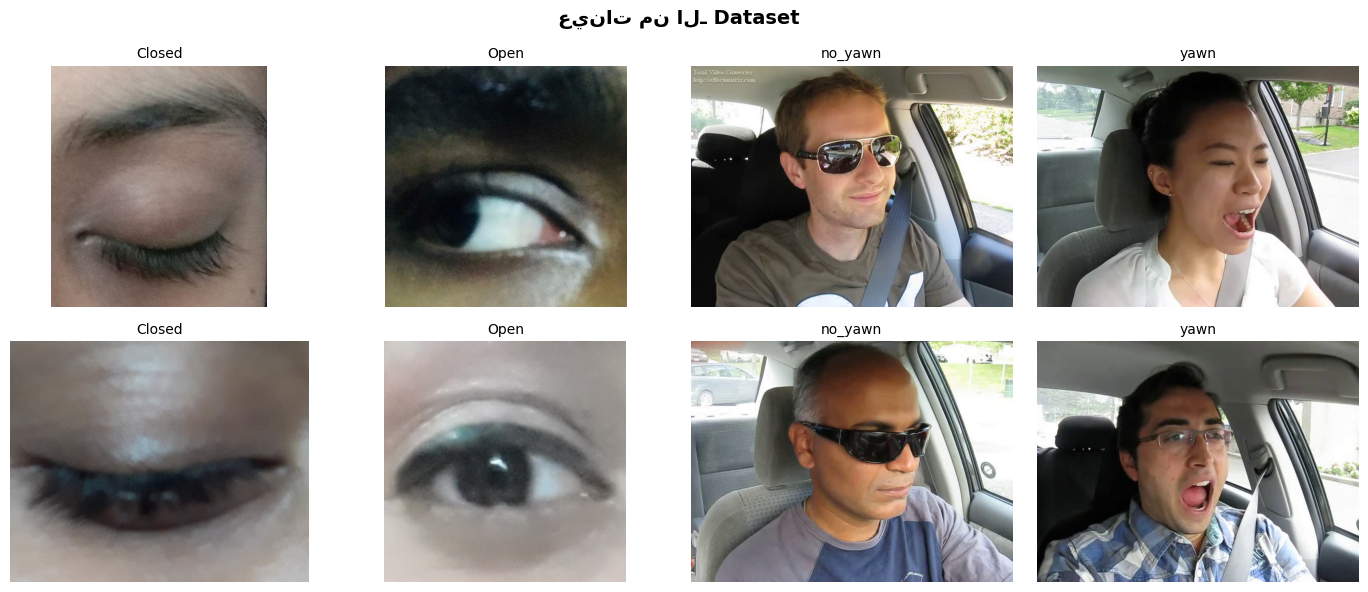

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

image_paths = []
labels_raw  = []

for class_dir in sorted(DATA_DIR.rglob("*")):
    if class_dir.is_dir():
        imgs = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
        if imgs:
            for img_path in imgs:
                image_paths.append(img_path)
                labels_raw.append(class_dir.name)

print(f"📊 إجمالي الصور: {len(image_paths):,}")
print(f"   الفئات: {Counter(labels_raw)}")

CLASS_NAMES = sorted(set(labels_raw))
print(f"\n   Class names: {CLASS_NAMES}")

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("عينات من الـ Dataset", fontsize=14, fontweight='bold')

for col, cls in enumerate(CLASS_NAMES[:4]):
    cls_imgs = [p for p, l in zip(image_paths, labels_raw) if l == cls]
    for row in range(2):
        ax = axes[row, col]
        img = Image.open(cls_imgs[row]).convert("RGB")
        ax.imshow(img)
        ax.set_title(cls, fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.show()


## 🏷️ 4. تحويل الفئات لـ Drowsiness Score

بدل ما نعمل classification (0 أو 1)، هنحوّل كل فئة لـ **continuous score** بين 0 و 1:

| الفئة | الدلالة | الـ Score |
|-------|---------|----------|
| `Open` | صاحي تماماً | 0.0 |
| `no_yawn` | طبيعي | 0.1 |
| `yawn` | بيتثاءب = بداية النعاس | 0.7 |
| `Closed` | عيون مغلقة = ناعس | 1.0 |


In [ ]:
DROWSINESS_MAP = {
    "Open":    0.0,
    "no_yawn": 0.1,
    "yawn":    0.7,
    "Closed":  1.0,
}

def get_score(label):

    if label in DROWSINESS_MAP:
        return DROWSINESS_MAP[label]

    label_lower = label.lower()
    if "closed" in label_lower:  return 1.0
    if "yawn"   in label_lower:  return 0.7
    if "open"   in label_lower:  return 0.0
    return 0.5  # unknown

drowsiness_scores = [get_score(l) for l in labels_raw]

print("📊 توزيع الـ Drowsiness Scores:")
for cls in CLASS_NAMES:
    score  = get_score(cls)
    count  = labels_raw.count(cls)
    bar    = "█" * (count // 50)
    print(f"   {cls:12s} → score={score:.1f}  |{bar}| {count:,} صورة")


📊 توزيع الـ Drowsiness Scores:
   Closed       → score=1.0  |██████████████| 726 صورة
   Open         → score=0.0  |██████████████| 726 صورة
   no_yawn      → score=0.1  |██████████████| 725 صورة
   yawn         → score=0.7  |██████████████| 723 صورة


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import random

class RealDrowsinessSequenceDataset(Dataset):

    def __init__(self, image_paths, labels, seq_len=10, img_size=64, augment=False):
        self.seq_len     = seq_len
        self.img_size    = img_size

        self.by_score = {}
        for path, label in zip(image_paths, labels):
            score = get_score(label)
            if score not in self.by_score:
                self.by_score[score] = []
            self.by_score[score].append(path)

        self.scores_sorted = sorted(self.by_score.keys())
        print(f"   Score levels available: {self.scores_sorted}")

        min_count     = min(len(v) for v in self.by_score.values())
        self.n_samples = min(500, min_count * 2)

        aug_transforms = [
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ] if augment else []

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            *aug_transforms,
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        frames, label_scores = [], []

        for t in range(self.seq_len):
            progress = t / (self.seq_len - 1)

            target_score = progress * max(self.scores_sorted)
            closest_score = min(self.scores_sorted, key=lambda s: abs(s - target_score))

            img_path = random.choice(self.by_score[closest_score])

            try:
                img    = Image.open(img_path).convert("RGB")
                frame  = self.transform(img)
            except Exception:
                frame  = torch.zeros(3, self.img_size, self.img_size)

            frames.append(frame)
            label_scores.append(closest_score)

        frames = torch.stack(frames)   # (T, 3, H, W)
        labels = torch.tensor(label_scores, dtype=torch.float32).unsqueeze(-1)  # (T, 1)
        return frames, labels

SEQ_LEN   = 10
IMG_SIZE  = 64

split_idx  = int(0.8 * len(image_paths))
idx_all    = list(range(len(image_paths)))
random.shuffle(idx_all)
train_idx, val_idx = idx_all[:split_idx], idx_all[split_idx:]

train_paths  = [image_paths[i] for i in train_idx]
train_labels = [labels_raw[i]  for i in train_idx]
val_paths    = [image_paths[i] for i in val_idx]
val_labels   = [labels_raw[i]  for i in val_idx]

print("📦 Building Train Dataset...")
train_dataset = RealDrowsinessSequenceDataset(train_paths, train_labels,
                                               seq_len=SEQ_LEN, img_size=IMG_SIZE,
                                               augment=True)
print(f"\n📦 Building Val Dataset...")
val_dataset   = RealDrowsinessSequenceDataset(val_paths, val_labels,
                                               seq_len=SEQ_LEN, img_size=IMG_SIZE,
                                               augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2)

f, l = train_dataset[0]
print(f"\n✅ Train: {len(train_dataset)} sequences | Val: {len(val_dataset)} sequences")
print(f"   Frame shape : {f.shape}")
print(f"   Label shape : {l.shape}")
print(f"   Label values: {l.squeeze().tolist()}")


📦 Building Train Dataset...
   Score levels available: [0.0, 0.1, 0.7, 1.0]

📦 Building Val Dataset...
   Score levels available: [0.0, 0.1, 0.7, 1.0]

✅ Train: 500 sequences | Val: 266 sequences
   Frame shape : torch.Size([10, 3, 64, 64])
   Label shape : torch.Size([10, 1])
   Label values: [0.0, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.699999988079071, 0.699999988079071, 0.699999988079071, 0.699999988079071, 1.0, 1.0]


In [ ]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, feature_dim=256, in_channels=3):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),          nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),         nn.BatchNorm2d(128),nn.ReLU(), nn.MaxPool2d(4),
        )
        self.reducer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, feature_dim),
            nn.ReLU(), nn.Dropout(0.3)
        )
    def forward(self, x):
        return self.reducer(self.backbone(x))


class LSTMSequenceLearner(nn.Module):
    def __init__(self, input_dim=256, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
    def forward(self, x, hidden=None):
        return self.lstm(x, hidden)


class DrowsinessScoreHead(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(),
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.scorer(x)


class CNNLSTMDrowsinessDetector(nn.Module):
    """
    Input : (batch, seq_len, 3, H, W)
    Output: (batch, seq_len, 1)  ← drowsiness score per frame
    """
    def __init__(self, feature_dim=256, hidden_dim=128, num_layers=2):
        super().__init__()
        self.cnn        = CNNFeatureExtractor(feature_dim)
        self.lstm       = LSTMSequenceLearner(feature_dim, hidden_dim, num_layers)
        self.score_head = DrowsinessScoreHead(hidden_dim)

    def forward(self, x):
        B, T, C, H, W = x.shape
        feats     = self.cnn(x.view(B*T, C, H, W)).view(B, T, -1)   # (B, T, feat)
        lstm_out, _ = self.lstm(feats)                                 # (B, T, hidden)
        scores    = self.score_head(lstm_out)                          # (B, T, 1)
        return scores, lstm_out, feats

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = CNNLSTMDrowsinessDetector(feature_dim=256, hidden_dim=128, num_layers=2)
model  = model.to(device)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model ready on {device}  |  Parameters: {params:,}")


✅ Model ready on cuda  |  Parameters: 956,289


In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for frames, labels in loader:
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        scores, _, _ = model(frames)
        loss = criterion(scores, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for frames, labels in loader:
            frames, labels = frames.to(device), labels.to(device)
            scores, _, _ = model(frames)
            total_loss += criterion(scores, labels).item()
    return total_loss / len(loader)

EPOCHS    = 15
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val = float('inf')

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'LR':>8}")
print("-" * 45)

for epoch in range(1, EPOCHS + 1):
    tr_loss  = train_epoch(model, train_loader, optimizer, criterion, device)
    v_loss   = val_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(v_loss)

    lr = optimizer.param_groups[0]['lr']
    flag = " ⭐" if v_loss < best_val else ""
    if v_loss < best_val:
        best_val = v_loss
        torch.save(model.state_dict(), "best_model.pth")

    print(f"{epoch:>6} | {tr_loss:>10.5f} | {v_loss:>10.5f} | {lr:>8.6f}{flag}")

print(f"\n✅ Best Val Loss: {best_val:.5f}  — saved to best_model.pth")


 Epoch | Train Loss |   Val Loss |       LR
---------------------------------------------
     1 |    0.06639 |    0.01295 | 0.001000 ⭐
     2 |    0.00962 |    0.00536 | 0.001000 ⭐
     3 |    0.00438 |    0.00261 | 0.001000 ⭐
     4 |    0.00260 |    0.00211 | 0.001000 ⭐
     5 |    0.00255 |    0.00189 | 0.000500 ⭐
     6 |    0.00200 |    0.00159 | 0.000500 ⭐
     7 |    0.00176 |    0.00179 | 0.000500
     8 |    0.00149 |    0.00128 | 0.000500 ⭐
     9 |    0.00109 |    0.00086 | 0.000500 ⭐
    10 |    0.00079 |    0.00064 | 0.000250 ⭐
    11 |    0.00064 |    0.00063 | 0.000250 ⭐
    12 |    0.00063 |    0.00047 | 0.000250 ⭐
    13 |    0.00059 |    0.00057 | 0.000250
    14 |    0.00050 |    0.00039 | 0.000250 ⭐
    15 |    0.00045 |    0.00029 | 0.000125 ⭐

✅ Best Val Loss: 0.00029  — saved to best_model.pth


## 📉 8. Training & Validation Loss

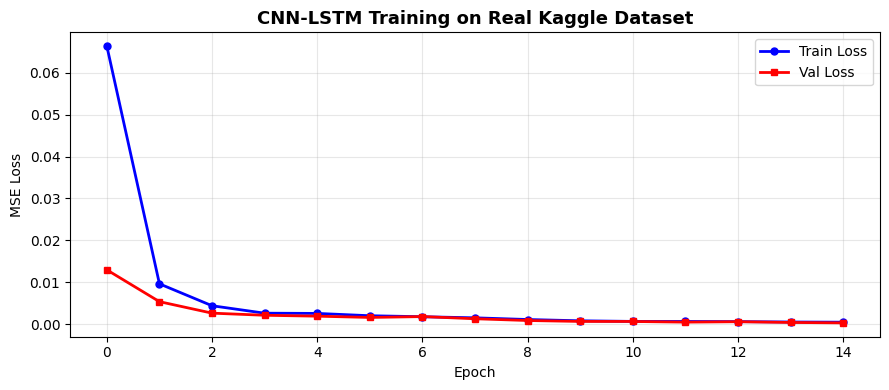

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(train_losses, 'b-o', linewidth=2, markersize=5, label='Train Loss')
plt.plot(val_losses,   'r-s', linewidth=2, markersize=5, label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("CNN-LSTM Training on Real Kaggle Dataset", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


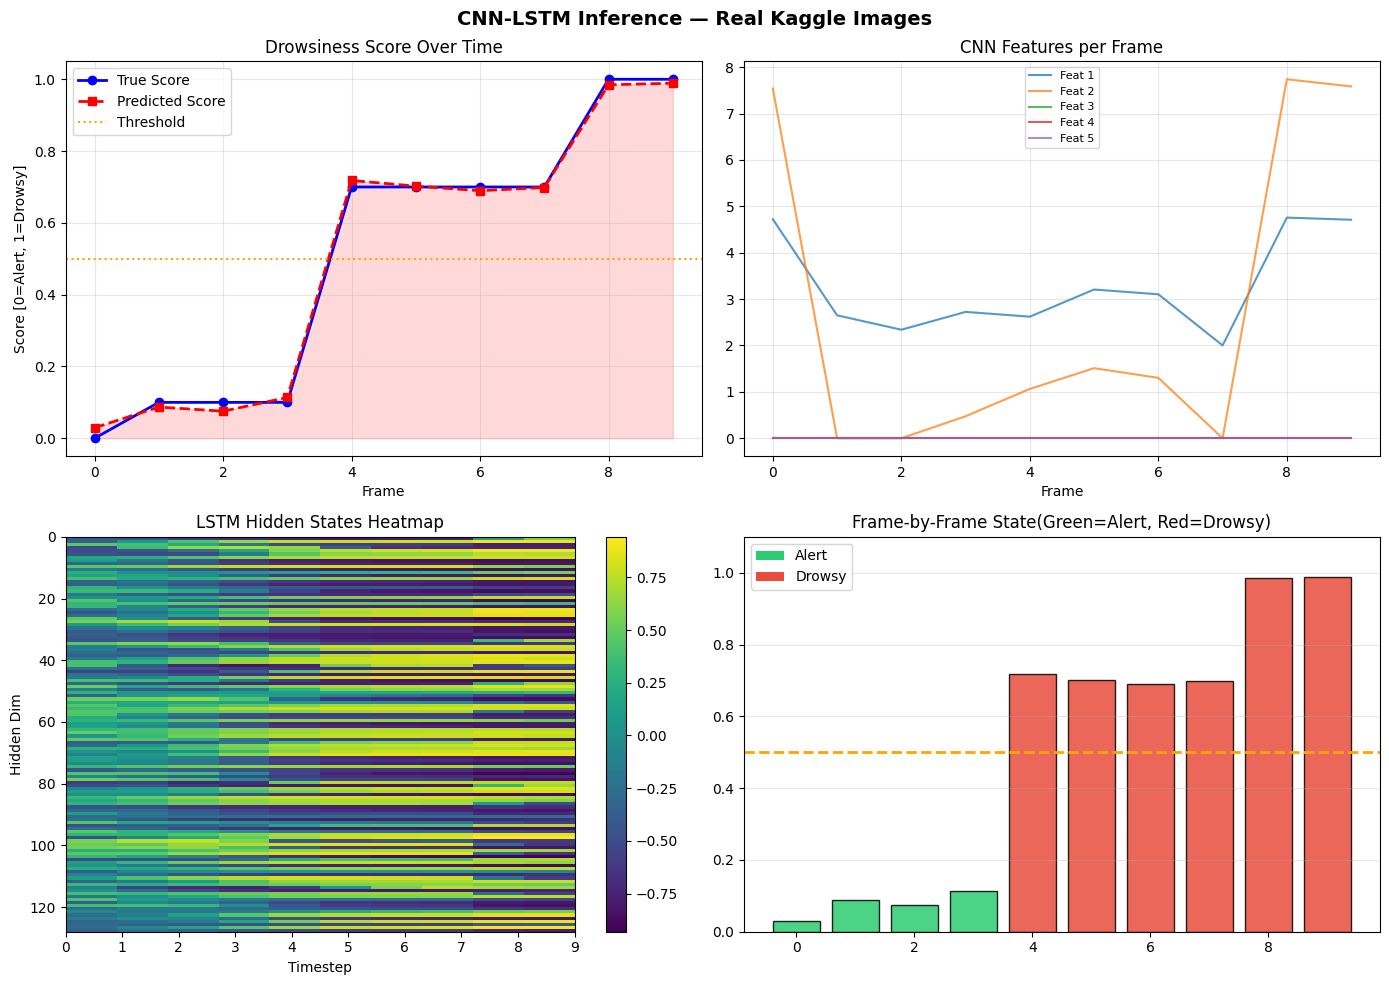

In [ ]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

frames, true_labels = val_dataset[0]
frames_in  = frames.unsqueeze(0).to(device)

with torch.no_grad():
    scores, lstm_out, cnn_feats = model(frames_in)

pred   = scores.squeeze().cpu().numpy()
true   = true_labels.squeeze().numpy()
timesteps = np.arange(SEQ_LEN)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("CNN-LSTM Inference — Real Kaggle Images", fontsize=14, fontweight='bold')

ax1 = axes[0, 0]
ax1.plot(timesteps, true, 'b-o', lw=2, label='True Score')
ax1.plot(timesteps, pred, 'r--s', lw=2, label='Predicted Score')
ax1.fill_between(timesteps, pred, alpha=0.15, color='red')
ax1.axhline(0.5, color='orange', ls=':', lw=1.5, label='Threshold')
ax1.set_title("Drowsiness Score Over Time"); ax1.set_ylim(-0.05, 1.05)
ax1.set_xlabel("Frame"); ax1.set_ylabel("Score [0=Alert, 1=Drowsy]")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
cnn_np = cnn_feats.squeeze(0).cpu().numpy()
for i in range(5):
    ax2.plot(timesteps, cnn_np[:, i], alpha=0.75, label=f'Feat {i+1}')
ax2.set_title("CNN Features per Frame"); ax2.set_xlabel("Frame")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
lstm_np = lstm_out.squeeze(0).cpu().numpy()
im = ax3.imshow(lstm_np.T, aspect='auto', cmap='viridis',
                extent=[0, SEQ_LEN-1, lstm_np.shape[1], 0])
plt.colorbar(im, ax=ax3)
ax3.set_title("LSTM Hidden States Heatmap")
ax3.set_xlabel("Timestep"); ax3.set_ylabel("Hidden Dim")

ax4 = axes[1, 1]
colors = ['#2ecc71' if s < 0.5 else '#e74c3c' for s in pred]
ax4.bar(timesteps, pred, color=colors, edgecolor='black', alpha=0.85)
ax4.axhline(0.5, color='orange', ls='--', lw=2)
ax4.set_title (f"Frame-by-Frame State(Green=Alert, Red=Drowsy)")
ax4.set_ylim(0, 1.1); ax4.grid(True, alpha=0.3, axis='y')
from matplotlib.patches import Patch
ax4.legend(handles=[Patch(facecolor='#2ecc71', label='Alert'),
                    Patch(facecolor='#e74c3c', label='Drowsy')])
plt.tight_layout(); plt.show()


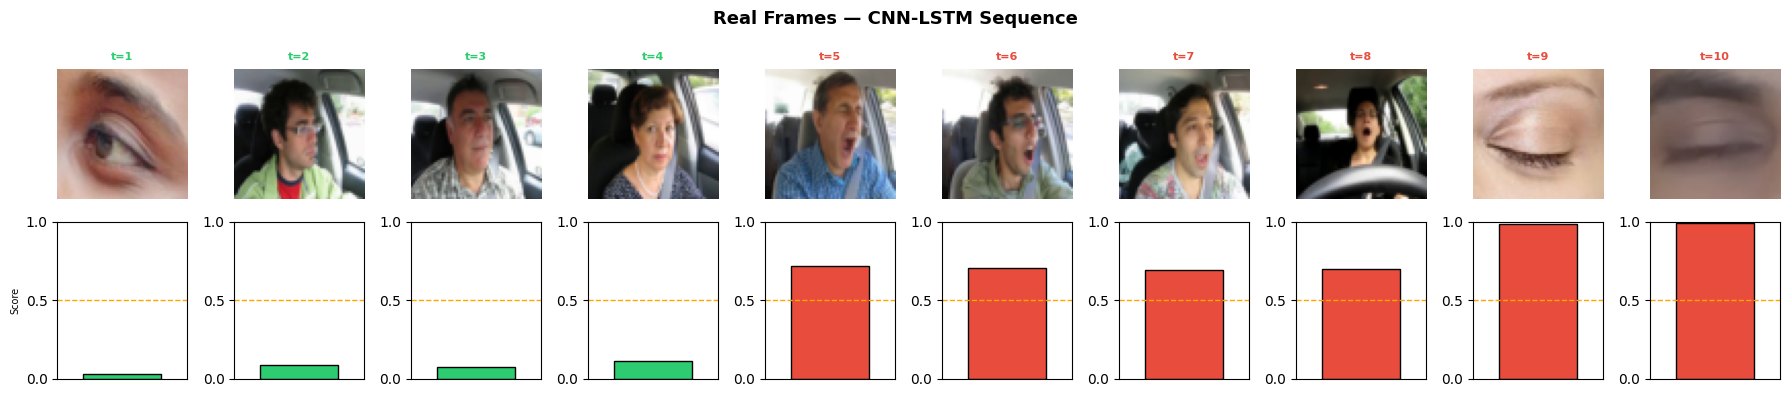


📋 Frame-by-Frame Report:
  Frame  1: [                         ] 0.029  👁️  ALERT 
  Frame  2: [██                       ] 0.087  👁️  ALERT 
  Frame  3: [█                        ] 0.075  👁️  ALERT 
  Frame  4: [██                       ] 0.114  👁️  ALERT 
  Frame  5: [█████████████████        ] 0.718  😴 DROWSY
  Frame  6: [█████████████████        ] 0.702  😴 DROWSY
  Frame  7: [█████████████████        ] 0.690  😴 DROWSY
  Frame  8: [█████████████████        ] 0.699  😴 DROWSY
  Frame  9: [████████████████████████ ] 0.985  😴 DROWSY
  Frame 10: [████████████████████████ ] 0.989  😴 DROWSY


In [ ]:
fig, axes = plt.subplots(2, SEQ_LEN, figsize=(18, 4))
fig.suptitle("Real Frames — CNN-LSTM Sequence", fontsize=13, fontweight='bold')

for t in range(SEQ_LEN):

    ax_img = axes[0, t]
    img_t  = frames[t].permute(1, 2, 0).numpy()
    img_t  = (img_t * 0.5 + 0.5).clip(0, 1)  # de-normalize
    ax_img.imshow(img_t)
    ax_img.axis("off")
    color = '#e74c3c' if pred[t] > 0.5 else '#2ecc71'
    ax_img.set_title(f"t={t+1}", fontsize=8, color=color, fontweight='bold')

    ax_bar = axes[1, t]
    ax_bar.bar([0], [pred[t]], color=color, width=0.6, edgecolor='black')
    ax_bar.set_ylim(0, 1); ax_bar.set_xlim(-0.5, 0.5)
    ax_bar.set_xticks([]); ax_bar.set_yticks([0, 0.5, 1])
    ax_bar.axhline(0.5, color='orange', ls='--', lw=1)
    ax_bar.set_ylabel("Score" if t == 0 else "", fontsize=7)

plt.tight_layout()
plt.show()

print("\n📋 Frame-by-Frame Report:")
for t in range(SEQ_LEN):
    state = "😴 DROWSY" if pred[t] > 0.5 else "👁️  ALERT "
    bar   = "█" * int(pred[t] * 25)
    print(f"  Frame {t+1:2d}: [{bar:<25}] {pred[t]:.3f}  {state}")
